# LRP-RL Training Notebook
**Location Routing Problem with Autonomous Vehicle Safety Constraints**

## Cell 1

In [1]:
import os

# Remove old clone if exists
if os.path.exists('/content/RL'):
    print('Removing existing clone...')
    !rm -rf /content/RL

# Clone the repository
print('Cloning from GitHub...')
!git clone https://github.com/MotahareG/RL.git /content/RL

# Navigate to project directory
os.chdir('/content/RL')
print(f'\nProject cloned successfully!')
print(f'Working directory: {os.getcwd()}')
!ls -la

Cloning from GitHub...
Cloning into '/content/RL'...
remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 20 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (20/20), 310.83 KiB | 5.98 MiB/s, done.

Project cloned successfully!
Working directory: /content/RL
total 1208
drwxr-xr-x 3 root root   4096 Aug 22 10:44 .
drwxr-xr-x 1 root root   4096 Aug 22 10:44 ..
-rw-r--r-- 1 root root  24144 Aug 22 10:44 attention_agent.py
-rw-r--r-- 1 root root 669517 Aug 22 10:44 CA_AV_Collision_2019-2024.csv
-rw-r--r-- 1 root root   6875 Aug 22 10:44 configs.py
-rw-r--r-- 1 root root  28007 Aug 22 10:44 data_generator_lrp.py
-rw-r--r-- 1 root root   6901 Aug 22 10:44 decode_step.py
-rw-r--r-- 1 root root   1176 Aug 22 10:44 embeddings.py
drwxr-xr-x 8 root root   4096 Aug 22 10:44 .git
-rw-r--r-- 1 root root 309978 Aug 22 10:44 LRP_Colab_Github_revised.ipynb
-rw-r--r-- 1 root root  

In [2]:
rm -rf __pycache__


## Cell 2 — Set project path and verify files

In [3]:
import os, sys

PROJECT_DIR = '/content/RL'

os.chdir(PROJECT_DIR)
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

REQUIRED = [
    'train_lrp.py', 'lrp_env.py', 'attention_agent.py',
    'vrp_attention.py', 'data_generator_lrp.py', 'decode_step.py',
    'embeddings.py', 'configs.py', 'misc_utils.py',
    'task_specific_params.py', 'visualize_routes.py',
    'visualize_clustering.py', 'visualize_lrp.py',
    'CA_AV_Collision_2019-2024.csv',
]
missing = [f for f in REQUIRED if not os.path.exists(f)]
if missing:
    print('Missing files — upload them to', PROJECT_DIR)
    for f in missing:
        print('  ', f)
else:
    print('All required files found')
    print('Working dir:', os.getcwd())

All required files found
Working dir: /content/RL


## Cell 3 — GPU check and dependencies

In [4]:
!pip install -q scikit-learn scipy pandas matplotlib numpy folium

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print('TensorFlow:', tf.__version__)
if gpus:
    print('GPU:', gpus[0].name, 'Ready')
else:
    print('WARNING: No GPU detected.')
    print('Go to Runtime > Change runtime type > T4 GPU, then re-run from Cell 1.')


TensorFlow: 2.20.0
GPU: /physical_device:GPU:0 Ready


## Cell 4 — Risk Map Visualisation (K-means clustering)


Running: python visualize_clustering.py --csv=CA_AV_Collision_2019-2024.csv --n_fac=5 --html=/content/figures/california_risk_map.html --static=/content/figures/california_risk_map_static.png
CALIFORNIA AV COLLISION RISK MAP  (OpenStreetMap + K-means)

[1/3] Loading collision data ...
  646 records.
[2/3] K-means (5 clusters) ...

CANDIDATE STATION LOCATIONS  (n_fac = 5)
ID     Latitude   Longitude    NLat    NLon  Accidents
----------------------------------------------------------------------
S1      37.7703   -122.4219  0.5548  0.1979        504
S2      34.0033   -118.3494  0.1582  0.5858         40
S3      32.7061   -116.7161  0.0217  0.7413          2
S4      37.4145   -122.0516  0.5173  0.2332         96
S5      33.6664   -117.8344  0.1228  0.6348          4

[3/3] Generating outputs ...
✅  Interactive OSM map → /content/figures/california_risk_map.html
✅  Static figure → /content/figures/california_risk_map_static.png


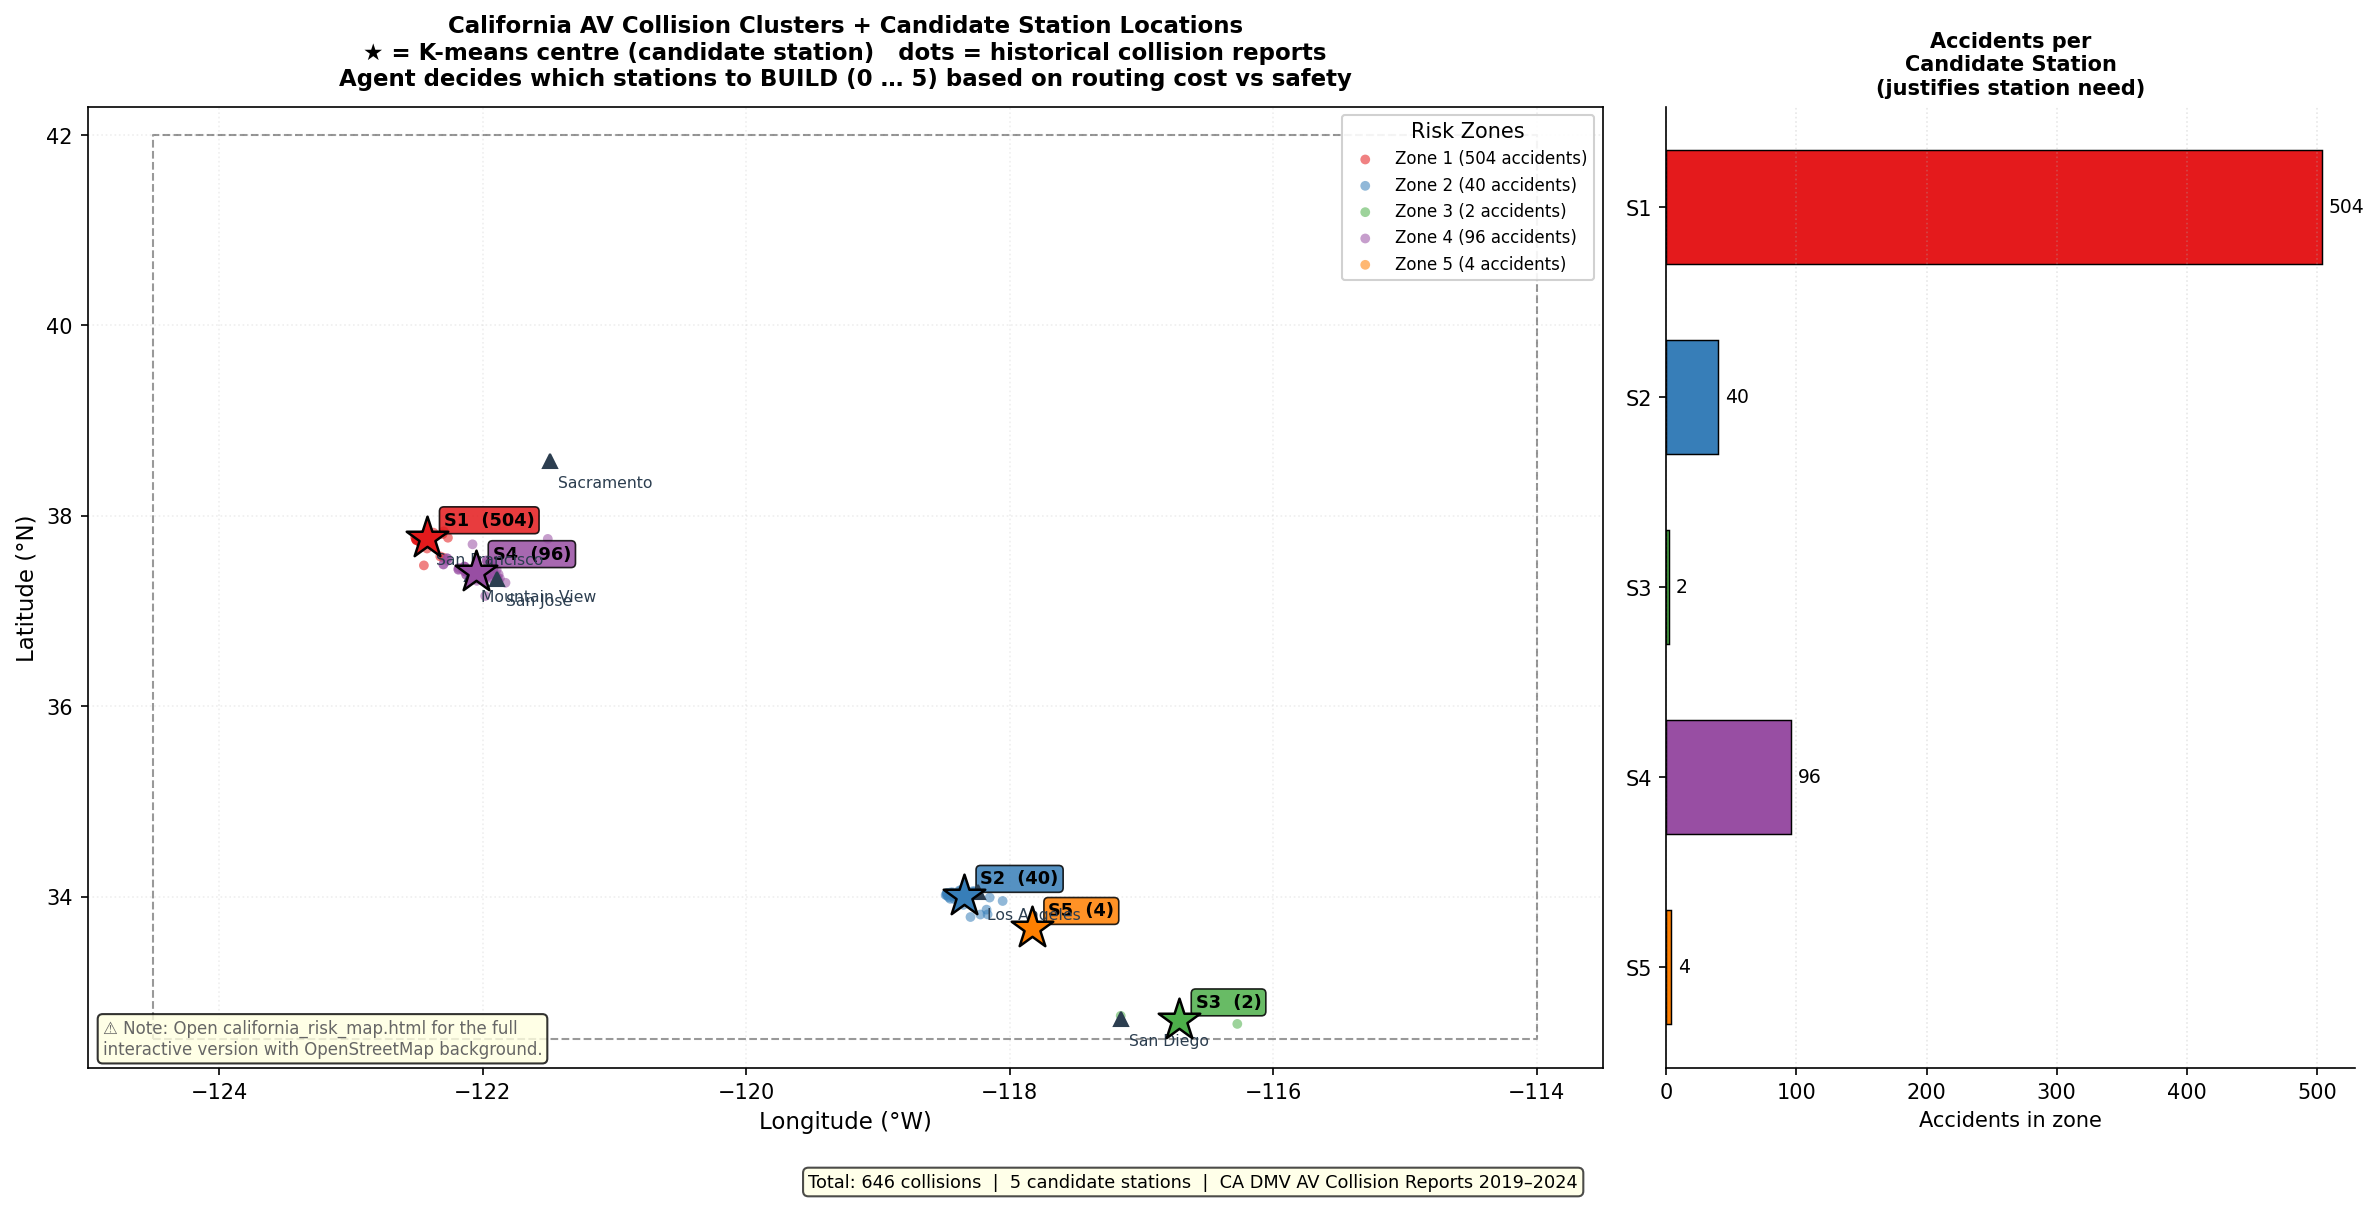

/usr/local/lib/python3.13/dist-packages/IPython/core/display.py:724: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


In [5]:
import os, sys

N_FAC_VIZ = 5        # must match N_FAC in Cell 5

os.makedirs('/content/figures', exist_ok=True)

cmd = (
    f'python visualize_clustering.py'
    f' --csv=CA_AV_Collision_2019-2024.csv'
    f' --n_fac={N_FAC_VIZ}'
    f' --html=/content/figures/california_risk_map.html'
    f' --static=/content/figures/california_risk_map_static.png'
)
print('Running:', cmd)
!{cmd}

from IPython.display import Image, HTML, display
static = '/content/figures/california_risk_map_static.png'
if os.path.exists(static):
    display(Image(static, width=900))
else:
    print('[WARNING] Static figure not found.')

html_path = '/content/figures/california_risk_map.html'
if os.path.exists(html_path):
    display(HTML(f'<iframe src="{html_path}" width="100%" height="560" style="border:none"></iframe>'))


## Cell 5 — Configure and run training



In [6]:
import os
os.makedirs('/content/figures', exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
# Training Hyperparameters  ← edit here
# ══════════════════════════════════════════════════════════════════════════════
TASK             = 'lrp20'   # lrp8 | lrp10 | lrp20 | lrp50 | lrp100
N_INSTANCES      = 10000
N_EPOCHS         = 100
BATCH_SIZE       = 64
N_LAMBDA_SAMPLES = 5         # 5 = fast (98% accuracy); 10 = slower, more precise
LOG_INTERVAL     = 200
SAVE_INTERVAL    = 6000
ACTOR_LR         = '1e-4'
CRITIC_LR        = '1e-4'

# ── Disable mid-training evaluation ──────────────────────────────────────────
# Setting TEST_INTERVAL larger than total steps means evaluate_batch() is never
# called during training. A single post-training evaluation runs in Cell 7
# with precise per-instance timing.
TOTAL_STEPS      = N_INSTANCES // BATCH_SIZE * N_EPOCHS
TEST_INTERVAL    = TOTAL_STEPS + 1   # effectively ∞

# ── Build command ─────────────────────────────────────────────────────────────
LOG_DIR = '/content/logs'
FIG_DIR = '/content/figures'
os.makedirs(LOG_DIR, exist_ok=True)

cmd = (
    f'python train_lrp.py'
    f' --task={TASK}'
    f' --use_fixed_dataset=True'
    f' --n_instances={N_INSTANCES}'
    f' --n_epochs={N_EPOCHS}'
    f' --batch_size={BATCH_SIZE}'
    f' --log_interval={LOG_INTERVAL}'
    f' --test_interval={TEST_INTERVAL}'
    f' --save_interval={SAVE_INTERVAL}'
    f' --actor_net_lr={ACTOR_LR}'
    f' --critic_net_lr={CRITIC_LR}'
    f' --is_train=True'
    f' --gpu=0'
)

print('═' * 70)
print('TRAINING  (no mid-training evaluation)')
print('═' * 70)
print(f'Problem:      {TASK}')
print(f'Dataset:      {N_INSTANCES:,} train instances')
print(f'Epochs:       {N_EPOCHS}  |  batch: {BATCH_SIZE}')
print(f'Total steps:  {TOTAL_STEPS:,}')
print(f'TEST_INTERVAL set to {TEST_INTERVAL} → evaluation disabled during training')
print(f'Evaluation + timing: Cell 7')
print('═' * 70)
print()
!{cmd}


══════════════════════════════════════════════════════════════════════
TRAINING  (no mid-training evaluation)
══════════════════════════════════════════════════════════════════════
Problem:      lrp20
Dataset:      10,000 train instances
Epochs:       100  |  batch: 64
Total steps:  15,600
TEST_INTERVAL set to 15601 → evaluation disabled during training
Evaluation + timing: Cell 7
══════════════════════════════════════════════════════════════════════

Instructions for updating:
non-resource variables are not supported in the long term
actor_net_lr: 0.0001
agent_type: attention
batch_size: 64
beam_width: 10
capacity_per_compartment: 10.0
critic_net_lr: 0.0001
data_dir: data
decode_len: 36
demand_max: 10
disable_tqdm: True
dropout: 0.1
embedding_dim: 128
entropy_coeff: 0.0
facility_opening_cost: 0.0027397260273972603
forget_bias: 1.0
gpu: 0
hidden_dim: 128
infer_type: batch
input_dim: 4
is_train: True
learning_rate: 0.0001
load_path: 
log_dir: logs/lrp20-2026-08-22_10-45-29
log_interval:

In [ ]:
from google.colab import files
files.download('logs/lrp30-2026-06-30_12-55-43/training_history.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Instructions for updating:
non-resource variables are not supported in the long term


Cell 6 — Inference + Export + Map  |  Task: lrp20
Facility cost (C_j/H): 0.002740

[1/5] Locating checkpoint for task: lrp20
  Found in: /content/RL/logs
  Checkpoint: final_model.ckpt
  n_cust=20  n_fac=8  n_nodes=29  decode_len=36

[2/5] Building data generator and test set...
  [Stage 1] Loading collision data and fitting KDE ...
  646 collision points loaded.
  Risk grid: 200x200, 189 risky cells (0.47% of map)
  [Stage 2] K-means (8 clusters) ...
    Candidate S1: (37.4060N, 122.0983W)
    Candidate S2: (34.0033N, 118.3494W)
    Candidate S3: (37.7717N, 122.4223W)
    Candidate S4: (32.7485N, 117.1586W)
    Candidate S5: (33.6664N, 117.8344W)
    Candidate S6: (32.6637N, 116.2736W)
    Candidate S7: (37.4038N, 121.9248W)
    Candidate S8: (37.5480N, 122.2837W)
  Computing lambda for 1 instances ...  Lambda done (1 instances).
  Building test set (50 instances) ...
  Computing lambda for 50 test instances ...  Lambda done (50 instances).
  Test set: (50, 29, 4)
  Test set: 50 insta

/usr/local/lib/python3.13/dist-packages/tensorflow/python/keras/layers/legacy_rnn/rnn_cell_impl.py:910: UserWarning: `tf.nn.rnn_cell.LSTMCell` is deprecated and will be removed in a future version. This class is equivalent as `tf.keras.layers.LSTMCell`, and will be replaced by that in Tensorflow 2.0.
  warnings.warn("`tf.nn.rnn_cell.LSTMCell` is deprecated and will be "
/usr/local/lib/python3.13/dist-packages/tensorflow/python/keras/engine/base_layer_v1.py:1702: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use `layer.add_weight` method instead.
  warnings.warn('`layer.add_variable` is deprecated and '
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


  Loaded: final_model.ckpt

[4/5] Running inference...
  Avg cost: 5.4734  |  Inference: 8.11s
  ─ Avg opened facilities: 0.04
  ─ Avg facility cost:     0.0001  (= 0.04 × 0.002740)
  ─ Avg routing cost:      5.4733

[5/5] Exporting 50 instances...
  10/50 exported...
  20/50 exported...
  30/50 exported...
  40/50 exported...
  50/50 exported...
  ✓ Exported to /content/gams_export

Generating maps (4 instances)...
  Grid: /content/figures/route_grid_lrp20.png
  Map: /content/figures/route_map_lrp20_inst0.html


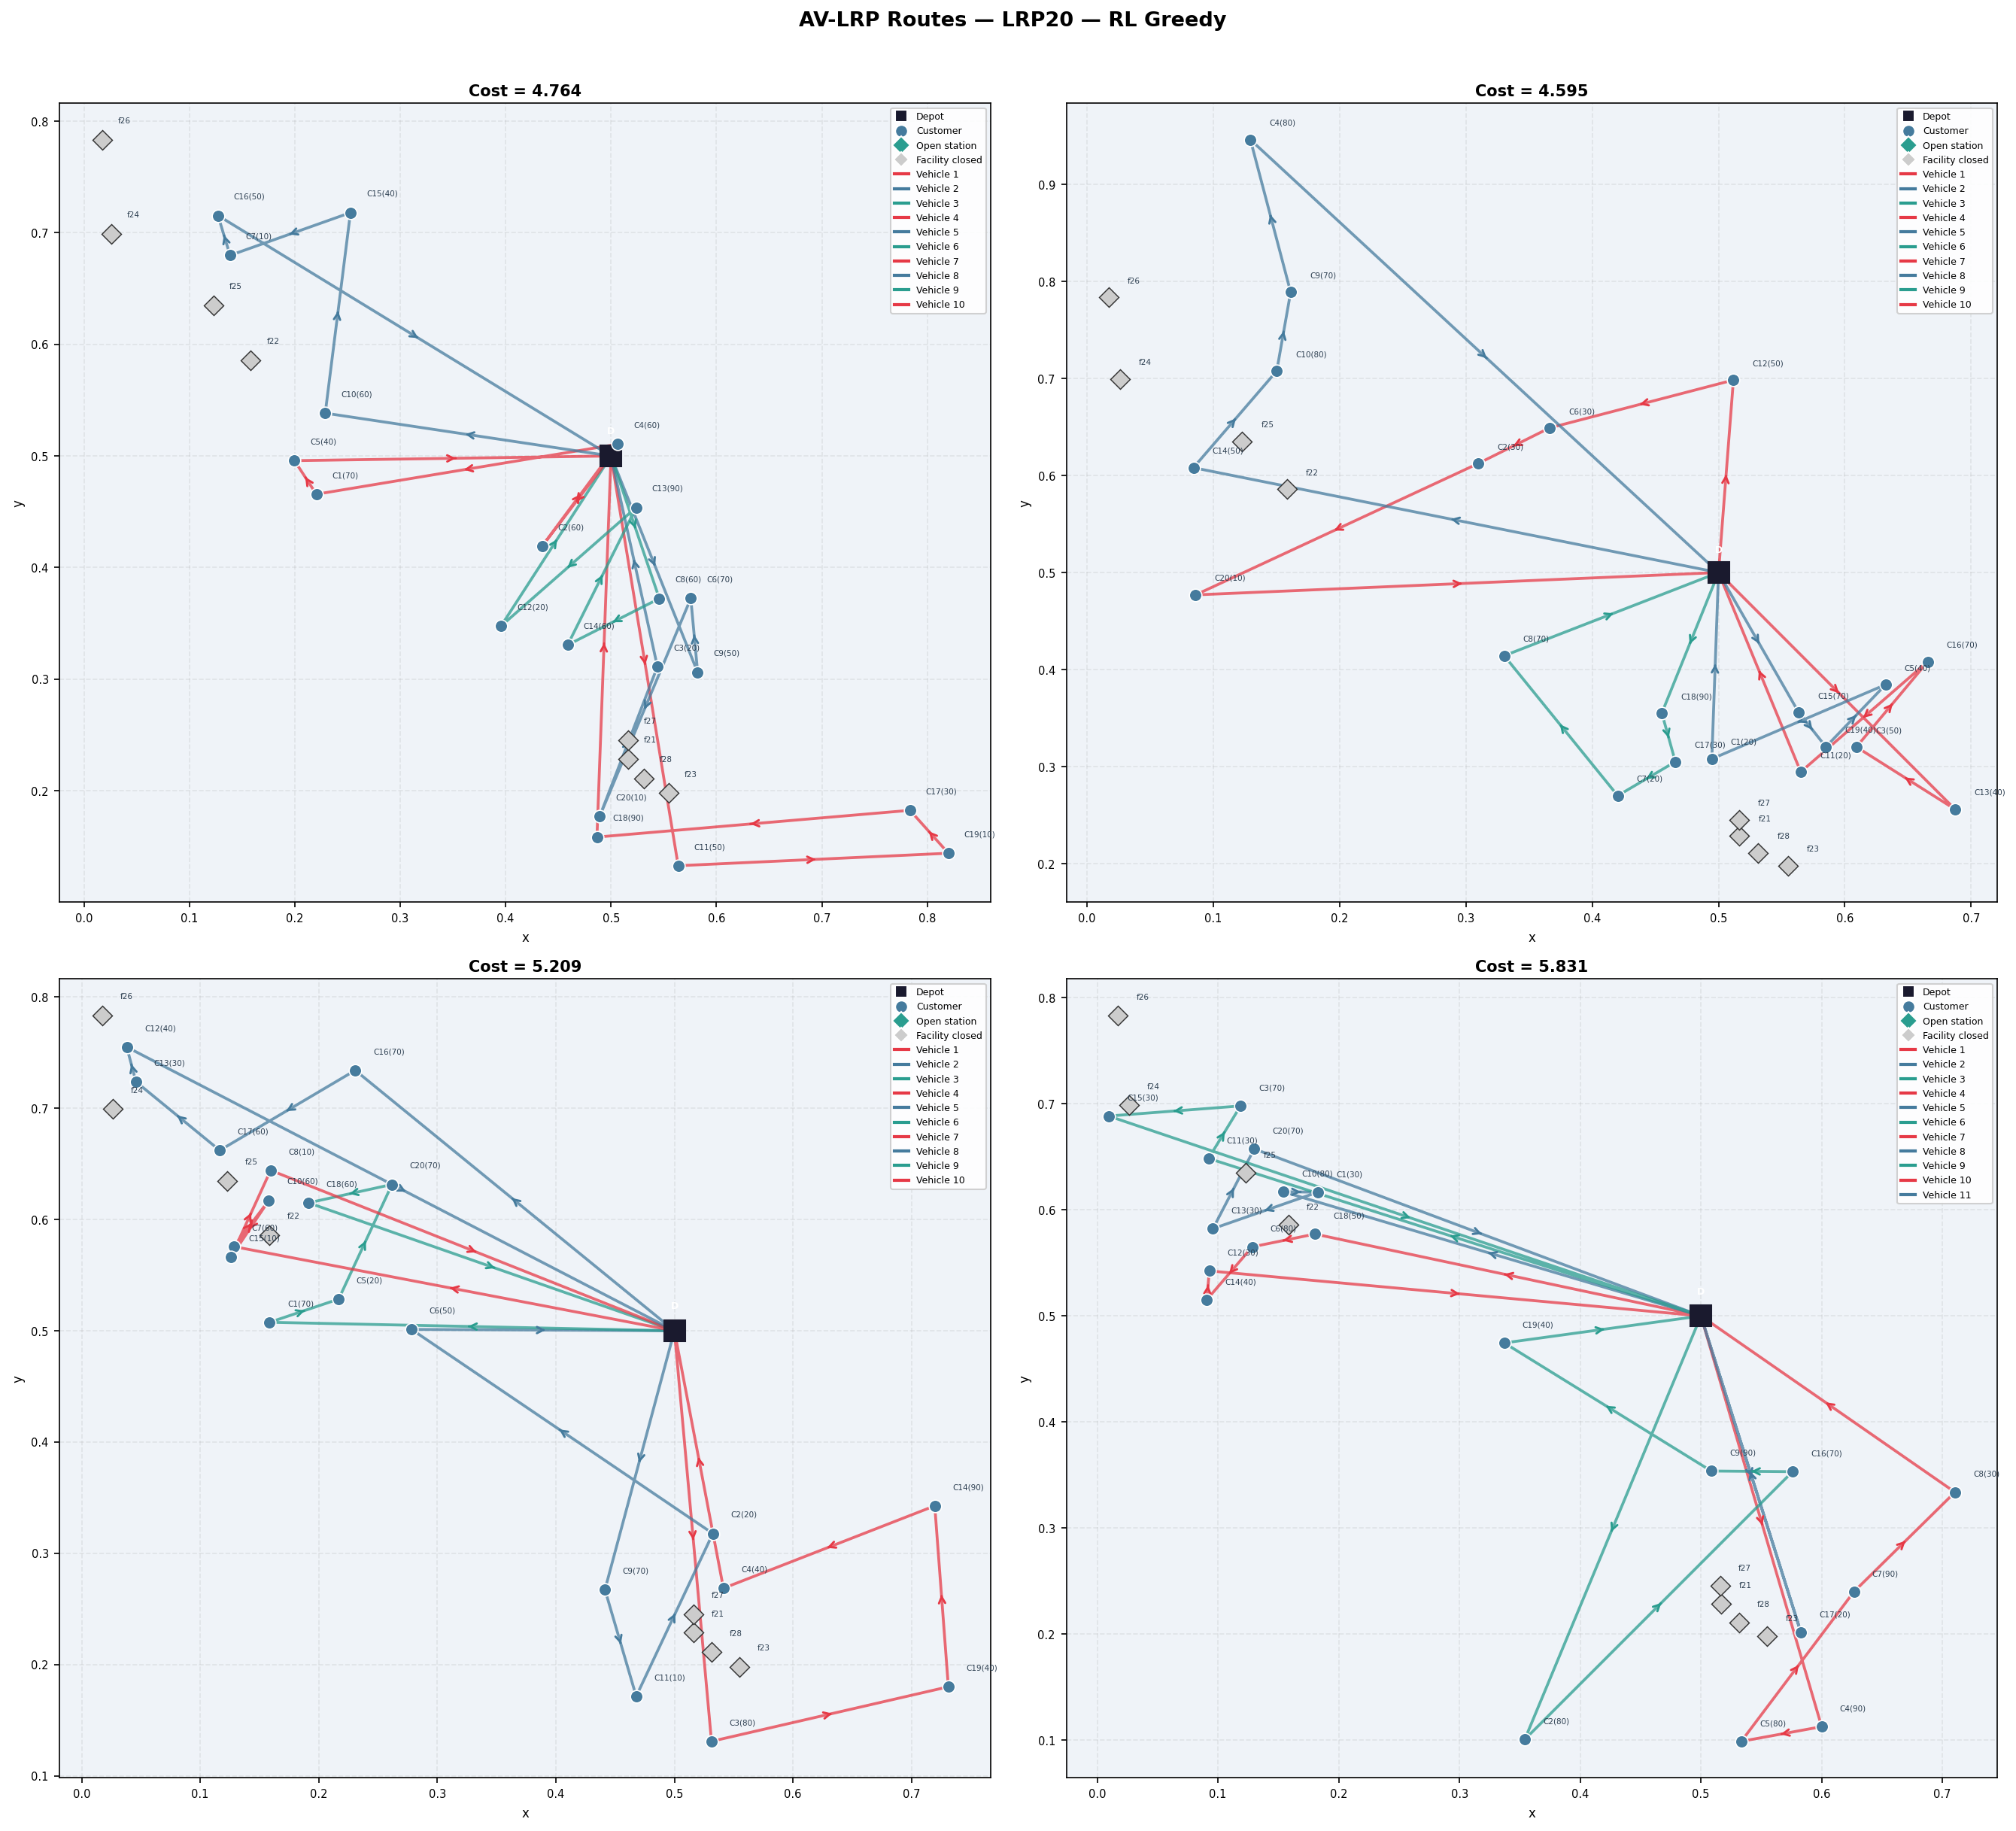

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


SUMMARY
  Task                : lrp20
  Test instances      : 50
  RL avg cost         : 5.4734 ± 0.6842
  Facility cost (C_j/H): 0.002740
  Avg opened fac      : 0.04  (هزینه facility = 0.0001)
  Avg routing cost    : 5.4733
  CSV exported to     : /content/gams_export/
  Route grid          : /content/figures/route_grid_lrp20.png
  Interactive map     : /content/figures/route_map_lrp20_inst0.html


In [7]:
# ╔═════════════════════════════════════════════════════════════════════════════╗
# ║  Cell 6 — Inference · Export to GAMS · Route Visualization                ║
# ║  نسخه اصلاح‌شده (post-defence): C1 حذف، هزینه facility = C_j/H         ║
# ╚═════════════════════════════════════════════════════════════════════════════╝

import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'folium'], check=False)

import os, sys, glob, json, csv, time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import folium
from IPython.display import display, HTML, Image

# ── تنظیمات قابل تغییر ─────────────────────────────────────────────────────────
try:
    _TASK   = TASK
    _LOGDIR = LOG_DIR
except NameError:
    _TASK   = 'lrp20'
    _LOGDIR = '/content/logs'

N_TEST_EXPORT   = 50
N_MAP_SHOW      = 4
EXPORT_DIR      = '/content/gams_export'
FIGURES_DIR     = '/content/figures'
os.makedirs(EXPORT_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── پارامترهای مدل اصلاح‌شده ──────────────────────────────────────────────────
CF = 10.0       # هزینه ساخت ایستگاه (C_j)
HF = 3650.0     # افق برنامه‌ریزی (H) — به روز
FACILITY_COST = CF / HF   # ≈ 0.00274

LAT_MIN, LAT_MAX =  32.5,  42.0
LON_MIN, LON_MAX = -124.5, -114.0
VEHICLE_COLORS = ['#E63946','#457B9D','#2A9D8F']
NODE_COLORS = {
    'depot':      '#1A1A2E',
    'customer':   '#457B9D',
    'fac_open':   '#2A9D8F',
    'fac_closed': '#CCCCCC',
}
print('='*65)
print(f'Cell 6 — Inference + Export + Map  |  Task: {_TASK}')
print(f'Facility cost (C_j/H): {FACILITY_COST:.6f}')
print('='*65)

# ── path & imports ─────────────────────────────────────────────────────────────
PROJECT_DIR = '/content/RL'
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)
os.chdir(PROJECT_DIR)

import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

from configs            import ParseParams, initialize_task_settings
from lrp_env            import Env
from data_generator_lrp import LRPDataGenerator
from attention_agent    import RLAgent
import misc_utils as utils

try:
    from vrp_attention import AttentionVRPActor, AttentionVRPCritic
except ImportError:
    from VRP.vrp_attention import AttentionVRPActor, AttentionVRPCritic

# ── reward function (matches revised model: C_j/H facility cost) ──────────────
def _lrp_reward_func(
        actions,
        opened_facilities      = None,
        facility_opening_cost  = FACILITY_COST):
    """
    R(τ) = −( routing_cost + facility_cost )
    هزینه facility = (C_j/H) × تعداد ایستگاه‌های باز
    """
    sample   = tf.stack(actions, axis=0)
    shifted  = tf.concat([tf.expand_dims(sample[-1], 0), sample[:-1]], axis=0)
    route_lengths = tf.reduce_sum(
        tf.sqrt(tf.reduce_sum(tf.square(shifted - sample), axis=2)), axis=0)

    fac_cost = tf.constant(0.0)
    if opened_facilities is not None:
        n_opened = tf.reduce_sum(opened_facilities, axis=1)
        if isinstance(facility_opening_cost, (int, float)):
            fac_cost = tf.cast(n_opened, tf.float32) * float(facility_opening_cost)
        else:
            fac_cost = tf.reduce_sum(opened_facilities * facility_opening_cost, axis=1)

    return -(route_lengths + fac_cost)

# ── checkpoint search ──────────────────────────────────────────────────────────
print(f'\n[1/5] Locating checkpoint for task: {_TASK}')
_search_roots = [
    f'{PROJECT_DIR}/logs',
    _LOGDIR,
    os.path.join(os.getcwd(), 'logs'),
    'logs',
]
checkpoint_dirs = []
for root in _search_roots:
    checkpoint_dirs  = sorted(glob.glob(f'{root}/{_TASK}*/model'))
    if not checkpoint_dirs:
        checkpoint_dirs = sorted(glob.glob(f'{root}/lrp*/model'))
    if checkpoint_dirs:
        print(f'  Found in: {root}')
        break
if not checkpoint_dirs:
    checkpoint_dirs = sorted(glob.glob(f'/content/**/{_TASK}*/model', recursive=True))
if not checkpoint_dirs:
    raise FileNotFoundError(
        f'Checkpoint not found. Searched: {_search_roots}\n'
        'Run Cell 5 first.')

model_dir = checkpoint_dirs[-1]
ckpt = tf.train.latest_checkpoint(model_dir)
if ckpt is None:
    raise FileNotFoundError(f'No checkpoint in {model_dir}')
print(f'  Checkpoint: {os.path.basename(ckpt)}')

# ── build args ─────────────────────────────────────────────────────────────────
args = {
    'task': _TASK, 'task_name': 'lrp', 'is_lrp': True, 'is_train': False,
    'batch_size': N_TEST_EXPORT, 'test_size': N_TEST_EXPORT,
    'agent_type': 'attention', 'embedding_dim': 128, 'hidden_dim': 128,
    'n_process_blocks': 3, 'rnn_layers': 1, 'forget_bias': 1.0,
    'n_glimpses': 0, 'tanh_exploration': 10.0, 'use_tanh': True,
    'mask_glimpses': True, 'mask_pointer': True,
    'dropout': 0.0, 'beam_width': 1, 'infer_type': 'batch',
    'random_seed': 24601,
    'facility_opening_cost':  FACILITY_COST,   # C_j/H (revised model)
    'load_path':    model_dir,
    'log_dir':      os.path.dirname(model_dir),
    'model_dir':    model_dir,
    'figures_dir':  FIGURES_DIR,
    'stdout_print': True,
}
args = initialize_task_settings(args, _TASK)
print(f'  n_cust={args["n_cust"]}  n_fac={args["n_fac"]}  '
      f'n_nodes={args["n_nodes"]}  decode_len={args["decode_len"]}')

# ── data ───────────────────────────────────────────────────────────────────────
print('\n[2/5] Building data generator and test set...')
dataGen = LRPDataGenerator(
    args=args,
    collision_csv_path='CA_AV_Collision_2019-2024.csv',
    bounding_box=((32.5,-124.5),(42.0,-114.0)),
    grid_size=200)
args['collision_points'] = dataGen.collision_points

rep = dataGen.generate_instance(args['n_cust'], args['n_fac'],
                                seed=42, compute_lambda=True)
args['lambda_mat'] = rep['lambda']
args['node_type']  = rep['node_type']

features, lambda_data = dataGen.get_test_all()
features    = features[:N_TEST_EXPORT]
lambda_data = lambda_data[:N_TEST_EXPORT]
n_test   = features.shape[0]
n_nodes  = features.shape[1]

print(f'  Test set: {n_test} instances')

# ── build TF session ───────────────────────────────────────────────────────────
print('\n[3/5] Restoring weights...')
tf.reset_default_graph()
config_tf = tf.ConfigProto()
config_tf.gpu_options.allow_growth = True
sess = tf.Session(config=config_tf)
_dev_null = open('/dev/null', 'w')
prt = utils.printOut(_dev_null, stdout_print=False)

env   = Env(args)
agent = RLAgent(
    args=args, prt=prt, env=env, dataGen=dataGen,
    reward_func=_lrp_reward_func,
    clAttentionActor=AttentionVRPActor,
    clAttentionCritic=AttentionVRPCritic,
    is_train=False)
agent.Initialize(sess)
print(f'  Loaded: {os.path.basename(ckpt)}')

# ── inference (no mandatory_ph — C1 removed) ──────────────────────────────────
print('\n[4/5] Running inference...')
t0 = time.time()
R_arr, _, _, _, _, batch, _, routes = sess.run(
    agent.val_summary_greedy,
    feed_dict={
        agent.env.input_data:    features,
        agent.env.lambda_ph:     lambda_data,
        agent.decodeStep.dropout: 0.0,
    }
)
elapsed = time.time() - t0
avg_cost = float(-R_arr.mean())
print(f'  Avg cost: {avg_cost:.4f}  |  Inference: {elapsed:.2f}s')

# ── تحلیل هزینه ───────────────────────────────────────────────────────────────
total_fac_per_inst = []
for ii in range(n_test):
    n_fac_opened = sum(1 for n in routes[:, ii, 0]
                       if features[ii, int(n), 3] == 2.0)
    total_fac_per_inst.append(n_fac_opened)

avg_fac_opened   = float(np.mean(total_fac_per_inst))
avg_fac_cost     = avg_fac_opened * FACILITY_COST
avg_routing_cost = avg_cost - avg_fac_cost

print(f'  ─ Avg opened facilities: {avg_fac_opened:.2f}')
print(f'  ─ Avg facility cost:     {avg_fac_cost:.4f}  (= {avg_fac_opened:.2f} × {FACILITY_COST:.6f})')
print(f'  ─ Avg routing cost:      {avg_routing_cost:.4f}')

# ── export CSV ─────────────────────────────────────────────────────────────────
print(f'\n[5/5] Exporting {n_test} instances...')

def export_instance(idx):
    feats = features[idx]; lam = lambda_data[idx]
    coords = feats[:, :2]; demands = feats[:, 2]; ntypes = feats[:, 3]

    p_n = os.path.join(EXPORT_DIR, f'inst{idx:04d}_nodes.csv')
    with open(p_n, 'w', newline='') as f:
        w = csv.writer(f)
        w.writerow(['node','x','y','demand','node_type'])
        for i in range(n_nodes):
            w.writerow([i, round(float(coords[i,0]),6), round(float(coords[i,1]),6),
                        round(float(demands[i])*10,2), int(ntypes[i])])

    p_d = os.path.join(EXPORT_DIR, f'inst{idx:04d}_dist.csv')
    with open(p_d, 'w', newline='') as f:
        w = csv.writer(f)
        w.writerow(['i','j','dist'])
        for i in range(n_nodes):
            for j in range(n_nodes):
                if i != j:
                    d = float(np.sqrt(((coords[i]-coords[j])**2).sum()))
                    w.writerow([i, j, round(d,6)])

    p_l = os.path.join(EXPORT_DIR, f'inst{idx:04d}_lambda.csv')
    with open(p_l, 'w', newline='') as f:
        w = csv.writer(f)
        w.writerow(['i','j','lambda'])
        for i in range(n_nodes):
            for j in range(n_nodes):
                if i != j:
                    w.writerow([i, j, int(lam[i,j])])

    return float(-R_arr[idx])

exported_costs = []
for idx in range(n_test):
    exported_costs.append(export_instance(idx))
    if (idx+1) % 10 == 0:
        print(f'  {idx+1}/{n_test} exported...')

with open(os.path.join(EXPORT_DIR, 'summary.json'), 'w') as f:
    json.dump({'task': _TASK, 'n': n_test, 'avg_rl_cost': float(np.mean(exported_costs)),
               'facility_cost_per_unit': FACILITY_COST,
               'avg_fac_opened': avg_fac_opened,
               'avg_routing_cost': avg_routing_cost}, f, indent=2)
print(f'  ✓ Exported to {EXPORT_DIR}')

# ── helpers ────────────────────────────────────────────────────────────────────
def parse_tours(route_seq, depot_idx=0):
    tours, cur = [], [depot_idx]
    for nid in route_seq:
        cur.append(int(nid))
        if int(nid) == depot_idx and len(cur) > 2:
            tours.append(cur); cur = [depot_idx]
    if len(cur) > 2: tours.append(cur)
    return tours or [[depot_idx]]

def to_latlon(x, y):
    return (LAT_MIN + float(y)*(LAT_MAX-LAT_MIN),
            LON_MIN + float(x)*(LON_MAX-LON_MIN))

def draw_matplotlib(idx, ax):
    feats = features[idx]; route_seq = routes[:, idx, 0]
    # Determine opened facilities from the route (no mandatory pre-opening)
    opened = np.zeros(n_nodes, dtype=np.float32)
    for nid in route_seq:
        if feats[int(nid), 3] == 2.0: opened[int(nid)] = 1.0
    tours = parse_tours(route_seq); cost = float(-R_arr[idx])
    ax.set_facecolor('#EFF3F8'); ax.grid(True, alpha=0.25, linestyle='--')

    for t_i, tour in enumerate(tours):
        col = VEHICLE_COLORS[t_i % len(VEHICLE_COLORS)]
        xs=[float(feats[n,0]) for n in tour]; ys=[float(feats[n,1]) for n in tour]
        ax.plot(xs, ys, '-', color=col, lw=1.8, alpha=0.75, zorder=2)
        for k in range(len(xs)-1):
            mx=(xs[k]+xs[k+1])/2; my=(ys[k]+ys[k+1])/2
            dx=xs[k+1]-xs[k]; dy=ys[k+1]-ys[k]
            if dx*dx+dy*dy>1e-8:
                ax.annotate('',xy=(mx+dx*.01,my+dy*.01),xytext=(mx,my),
                            arrowprops=dict(arrowstyle='->',color=col,lw=1.4),zorder=3)

    for i in range(n_nodes):
        x,y=float(feats[i,0]),float(feats[i,1]); ntype=int(feats[i,3]); dem=float(feats[i,2])
        if ntype==0:
            ax.plot(x,y,'s',ms=13,color=NODE_COLORS['depot'],zorder=5)
            ax.text(x,y+.018,'D',ha='center',va='bottom',fontsize=6,
                    fontweight='bold',color='white',zorder=6)
        elif ntype==1:
            ax.plot(x,y,'o',ms=8,color=NODE_COLORS['customer'],mec='white',mew=.8,zorder=5)
            ax.text(x+.015,y+.015,f'C{i}({dem*10:.0f})',fontsize=5,color='#2C3E50',zorder=6)
        elif ntype==2:
            is_o=opened[i]>.5
            fc = NODE_COLORS['fac_open'] if is_o else NODE_COLORS['fac_closed']
            ax.plot(x,y,'D',ms=12 if is_o else 9,color=fc,mec='#333',mew=.7,zorder=5)
            ax.text(x+.015,y+.015,f'{"F" if is_o else "f"}{i}',
                    fontsize=5,color='#2C3E50',zorder=6)

    ax.set_title(f'Cost = {cost:.3f}',
                 fontsize=10, fontweight='bold', pad=5)
    ax.set_xlabel('x',fontsize=8); ax.set_ylabel('y',fontsize=8)
    ax.tick_params(labelsize=7)
    legend = [
        Line2D([0],[0],marker='s',color='w',mfc=NODE_COLORS['depot'],ms=8,label='Depot'),
        Line2D([0],[0],marker='o',color='w',mfc=NODE_COLORS['customer'],ms=8,label='Customer'),
        Line2D([0],[0],marker='D',color='w',mfc=NODE_COLORS['fac_open'],ms=8,label='Open station'),
        Line2D([0],[0],marker='D',color='w',mfc=NODE_COLORS['fac_closed'],ms=7,label='Facility closed'),
    ]+[Line2D([0],[0],color=VEHICLE_COLORS[t%len(VEHICLE_COLORS)],lw=2,label=f'Vehicle {t+1}')
       for t in range(len(tours))]
    ax.legend(handles=legend,loc='upper right',fontsize=6,framealpha=.9,handlelength=1.5)


def make_folium_map(idx):
    feats=features[idx]; route_seq=routes[:,idx,0]
    opened=np.zeros(n_nodes, dtype=np.float32)
    for nid in route_seq:
        if feats[int(nid),3]==2.0: opened[int(nid)]=1.0
    tours=parse_tours(route_seq); cost=float(-R_arr[idx])
    lats=[to_latlon(feats[i,0],feats[i,1])[0] for i in range(n_nodes)]
    lons=[to_latlon(feats[i,0],feats[i,1])[1] for i in range(n_nodes)]
    m=folium.Map(location=[np.mean(lats),np.mean(lons)],zoom_start=8,tiles='CartoDB positron')

    for t_i,tour in enumerate(tours):
        col=VEHICLE_COLORS[t_i%len(VEHICLE_COLORS)]
        pts=[to_latlon(feats[n,0],feats[n,1]) for n in tour]
        folium.PolyLine(pts,color=col,weight=3,opacity=.8,tooltip=f'Vehicle {t_i+1}').add_to(m)

    for i in range(n_nodes):
        lat,lon=to_latlon(feats[i,0],feats[i,1]); ntype=int(feats[i,3]); dem=float(feats[i,2])
        if ntype==0:
            folium.Marker([lat,lon],icon=folium.Icon(color='darkblue',icon='home',prefix='fa'),
                          tooltip='Depot').add_to(m)
        elif ntype==1:
            folium.CircleMarker([lat,lon],radius=7,color='white',weight=1.5,
                fill=True,fill_color=NODE_COLORS['customer'],fill_opacity=.9,
                tooltip=f'C{i} dem={dem*10:.1f}').add_to(m)
        elif ntype==2:
            is_o=opened[i]>.5
            fc=(NODE_COLORS['fac_open'] if is_o else NODE_COLORS['fac_closed'])
            lbl=('Open station' if is_o else 'Closed')
            folium.Marker([lat,lon],
                icon=folium.DivIcon(
                    html=f'<div style="background:{fc};border:2.5px solid #333;'
                         f'width:22px;height:22px;border-radius:4px;'
                         f'display:flex;align-items:center;justify-content:center;'
                         f'font-size:11px;font-weight:bold;color:#111;">F</div>',
                    icon_size=(22,22),icon_anchor=(11,11)),
                tooltip=f'F{i} [{lbl}]').add_to(m)

    title_html=(f'<div style="position:fixed;top:12px;left:50%;transform:translateX(-50%);'
                f'z-index:9999;background:rgba(255,255,255,.92);padding:6px 14px;'
                f'border-radius:6px;border:1px solid #999;font-family:Arial;'
                f'font-size:13px;font-weight:bold;white-space:nowrap;">'
                f'Cost: {cost:.4f}</div>')
    m.get_root().html.add_child(folium.Element(title_html))
    return m

# ── matplotlib grid ────────────────────────────────────────────────────────────
print(f'\nGenerating maps ({N_MAP_SHOW} instances)...')
ncols=min(2,N_MAP_SHOW); nrows=(N_MAP_SHOW+ncols-1)//ncols
fig,axes=plt.subplots(nrows,ncols,figsize=(ncols*9,nrows*8))
if N_MAP_SHOW==1: axes=[[axes]]
elif nrows==1:    axes=[axes]
for k in range(N_MAP_SHOW):
    draw_matplotlib(k,axes[k//ncols][k%ncols])
for k in range(N_MAP_SHOW,nrows*ncols):
    axes[k//ncols][k%ncols].set_visible(False)
plt.suptitle(f'AV-LRP Routes — {_TASK.upper()} — RL Greedy',
             fontsize=13,fontweight='bold',y=1.01)
plt.tight_layout()
grid_path=f'{FIGURES_DIR}/route_grid_{_TASK}.png'
plt.savefig(grid_path,dpi=150,bbox_inches='tight'); plt.show()
print(f'  Grid: {grid_path}')

# ── folium map ─────────────────────────────────────────────────────────────────
m0=make_folium_map(0)
map_path=f'{FIGURES_DIR}/route_map_{_TASK}_inst0.html'
m0.save(map_path); print(f'  Map: {map_path}')

display(Image(grid_path))
display(HTML(f'<div style="margin:8px 0;padding:8px 14px;background:#1F4E79;'
             f'border-radius:6px;display:inline-block;">'
             f'<a href="{map_path}" target="_blank" style="color:white;'
             f'font-weight:bold;text-decoration:none;">🗺️ نقشه تعاملی — Instance 0</a></div>'))

# ── download zip ───────────────────────────────────────────────────────────────
import shutil
zip_path=f'/content/gams_export_{_TASK}'
shutil.make_archive(zip_path,'zip',EXPORT_DIR)
try:
    from google.colab import files
    files.download(f'{zip_path}.zip')
except Exception:
    print(f'  ZIP: {zip_path}.zip')

# ── summary ────────────────────────────────────────────────────────────────────
print('\n'+'='*65)
print('SUMMARY')
print('='*65)
print(f'  Task                : {_TASK}')
print(f'  Test instances      : {n_test}')
print(f'  RL avg cost         : {np.mean(exported_costs):.4f} ± {np.std(exported_costs):.4f}')
print(f'  Facility cost (C_j/H): {FACILITY_COST:.6f}')
print(f'  Avg opened fac      : {avg_fac_opened:.2f}  (هزینه facility = {avg_fac_cost:.4f})')
print(f'  Avg routing cost    : {avg_routing_cost:.4f}')
print(f'  CSV exported to     : {EXPORT_DIR}/')
print(f'  Route grid          : {grid_path}')
print(f'  Interactive map     : {map_path}')
print('='*65)
sess.close()


In [ ]:
from google.colab import files
files.download('/content/figures/route_map_lrp30_inst0.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Table**

In [9]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  Cell — Edge Usage Table (run this AFTER EACH training run in Colab)      ║
# ║  نسخه اصلاح‌شده (post-defence): C1 حذف — بدون mandatory pre-opening     ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

# ── EDIT THESE TWO LINES BEFORE EACH RUN ─────────────────────────────────────
MODEL_DIR = '/content/RL/logs/lrp10-2026-06-29_14-55-25/model'   # ← model_dir of the run you just trained
CF_LABEL  = 10.0 / 3650.0                         # ← C_j/H value (revised model)
# ──────────────────────────────────────────────────────────────────────────────

TASK         = 'lrp20'
TEST_SIZE    = 1000
N_EDGES      = 200          # subset of test set used for the edge table
OUT_CSV      = '/content/figures/edge_usage_table.csv'

# ── پارامترهای مدل اصلاح‌شده ──
FACILITY_COST = 10.0 / 3650.0   # C_j/H

import os, sys, csv
import numpy as np
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

PROJECT_DIR = '/content/RL'
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)
os.chdir(PROJECT_DIR)

from configs            import initialize_task_settings
from lrp_env            import Env
from data_generator_lrp import LRPDataGenerator
from attention_agent    import RLAgent
import misc_utils as utils

try:
    from vrp_attention import AttentionVRPActor, AttentionVRPCritic
except ImportError:
    from VRP.vrp_attention import AttentionVRPActor, AttentionVRPCritic

def lrp_reward_func(actions, opened_facilities=None,
                     facility_opening_cost=FACILITY_COST, *a, **kw):
    sample  = tf.stack(actions, axis=0)
    shifted = tf.concat([tf.expand_dims(sample[-1], 0), sample[:-1]], axis=0)
    route_lengths = tf.reduce_sum(
        tf.sqrt(tf.reduce_sum(tf.square(shifted - sample), axis=2)), axis=0)
    fac_cost = tf.constant(0.0)
    if opened_facilities is not None:
        n_opened = tf.reduce_sum(opened_facilities, axis=1)
        fac_cost = tf.cast(n_opened, tf.float32) * float(facility_opening_cost)
    return -(route_lengths + fac_cost)


def build_edge_usage_table(route_seqs, feats, lambdas, depot_idx=0):
    """
    Edge usage analysis — revised model (no mandatory facilities).
    Opened facilities are determined solely from the route the agent walks.

    route_seqs : [decode_len, n_instances]
    feats      : [n_instances, n_nodes, 4]   (x, y, demand, node_type)
    lambdas    : [n_instances, n_nodes, n_nodes]
    """
    n_steps, n_inst = route_seqs.shape

    def _classify(a, b, lam, opened):
        if lam[a, b] == 1:
            return 'safe'
        return 'with_station' if (opened[a] > 0.5 or opened[b] > 0.5) else 'violated'

    real_total = real_safe = real_with_station = real_violated = 0
    closed_total = closed_safe = closed_with_station = closed_violated = 0

    for i in range(n_inst):
        seq  = route_seqs[:, i].astype(int)
        lam  = lambdas[i]
        nt   = feats[i, :, 3]

        # Opened facilities = those the agent actually visited
        opened = np.zeros(feats.shape[1], dtype=np.float32)
        for nid in seq:
            if nt[nid] == 2.0:
                opened[nid] = 1.0

        # ── REAL route edges: depot -> seq[0] -> seq[1] -> ... -> seq[T-1] ──
        full = np.concatenate([[depot_idx], seq])
        for t in range(len(full) - 1):
            a, b = full[t], full[t + 1]
            if a == b:
                continue
            real_total += 1
            cls = _classify(a, b, lam, opened)
            if cls == 'safe':            real_safe += 1
            elif cls == 'with_station':  real_with_station += 1
            else:                        real_violated += 1

        # ── OLD closed-tour convention (matches lrp_reward_func exactly) ───
        for t in range(n_steps):
            a, b = seq[t], seq[(t + 1) % n_steps]
            if a == b:
                continue
            closed_total += 1
            cls = _classify(a, b, lam, opened)
            if cls == 'safe':            closed_safe += 1
            elif cls == 'with_station':  closed_with_station += 1
            else:                        closed_violated += 1

    return dict(
        total_edges_used=real_total,
        safe_edges_used=real_safe,
        unsafe_edges_with_station=real_with_station,
        unsafe_edges_violated=real_violated,
        closed_tour_total_edges=closed_total,
        closed_tour_safe_edges=closed_safe,
        closed_tour_unsafe_with_station=closed_with_station,
        closed_tour_unsafe_violated=closed_violated,
    )


# ══════════════════════════════════════════════════════════════════════════════
# Load checkpoint + run greedy evaluation
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 70)
print(f"  EDGE USAGE EVAL  —  {TASK}  |  Cf = {CF_LABEL}")
print(f"  Checkpoint dir: {MODEL_DIR}")
print("=" * 70)

tf.reset_default_graph()

ckpt = tf.train.latest_checkpoint(MODEL_DIR)
if ckpt is None:
    raise FileNotFoundError(f"No checkpoint found in {MODEL_DIR}")
print(f"  Found checkpoint: {ckpt}")

args = {
    'task': TASK, 'task_name': 'lrp', 'is_lrp': True, 'is_train': False,
    'batch_size': TEST_SIZE, 'test_size': TEST_SIZE,
    'agent_type': 'attention', 'embedding_dim': 128, 'hidden_dim': 128,
    'n_process_blocks': 3, 'rnn_layers': 1, 'forget_bias': 1.0,
    'n_glimpses': 0, 'tanh_exploration': 10.0, 'use_tanh': True,
    'mask_glimpses': True, 'mask_pointer': True, 'dropout': 0.0,
    'beam_width': 1, 'infer_type': 'batch', 'random_seed': 24601,
    'facility_opening_cost': FACILITY_COST,  # C_j/H (revised model)
    'load_path': MODEL_DIR, 'log_dir': os.path.dirname(MODEL_DIR),
    'model_dir': MODEL_DIR, 'stdout_print': True,
}
args = initialize_task_settings(args, TASK)

dataGen = LRPDataGenerator(
    args=args, collision_csv_path='CA_AV_Collision_2019-2024.csv',
    bounding_box=((32.5, -124.5), (42.0, -114.0)), grid_size=200)
args['collision_points'] = dataGen.collision_points

rep = dataGen.generate_instance(args['n_cust'], args['n_fac'],
                                 seed=42, compute_lambda=True)
args['lambda_mat'] = rep['lambda']
args['node_type']  = rep['node_type']

config_tf = tf.ConfigProto()
config_tf.gpu_options.allow_growth = True
sess = tf.Session(config=config_tf)
prt = utils.printOut(open(os.path.join(os.path.dirname(MODEL_DIR),
                                        'edge_eval_log.txt'), 'w'),
                      stdout_print=False)

env = Env(args)
agent = RLAgent(
    args=args, prt=prt, env=env, dataGen=dataGen,
    reward_func=lambda actions, opened_facilities, fac_cost:
        lrp_reward_func(actions, opened_facilities, facility_opening_cost=fac_cost),
    clAttentionActor=AttentionVRPActor,
    clAttentionCritic=AttentionVRPCritic,
    is_train=False)
agent.Initialize(sess)
print(f"  Weights restored from: {ckpt}")

test_feat, test_lam = dataGen.get_test_all()
test_feat = test_feat[:TEST_SIZE]
test_lam  = test_lam[:TEST_SIZE]

R_arr, _, _, _, _, _, _, routes = sess.run(
    agent.val_summary_greedy,
    feed_dict={
        agent.env.input_data:    test_feat,
        agent.env.lambda_ph:     test_lam,
        agent.decodeStep.dropout: 0.0,
    })

avg_cost = float(-R_arr.mean())
edge_stats = build_edge_usage_table(
    routes[:, :N_EDGES, 0], test_feat[:N_EDGES], test_lam[:N_EDGES])

sess.close()

# ══════════════════════════════════════════════════════════════════════════════
# Print + accumulate results
# ══════════════════════════════════════════════════════════════════════════════
if 'edge_usage_rows' not in globals():
    edge_usage_rows = []

row = {
    'task': TASK, 'cf': CF_LABEL, 'avg_cost': avg_cost,
    **edge_stats,
}
edge_usage_rows.append(row)

print("\n" + "=" * 100)
print("EDGE USAGE TABLE — REAL ROUTE (depot -> ... -> last node)  [use this for safety claims]")
print(f"{'Problem':<18} | {'Total edges used':>17} | {'Safe edges used':>16} | "
      f"{'Unsafe w/ station':>18} | {'Unsafe violated':>16}")
print("-" * 100)
for r in edge_usage_rows:
    lbl = f"{r['task']} (Cf={r['cf']:.6f})"
    print(f"{lbl:<18} | {r['total_edges_used']:>17} | {r['safe_edges_used']:>16} | "
          f"{r['unsafe_edges_with_station']:>18} | {r['unsafe_edges_violated']:>16}")

print("\n" + "=" * 100)
print("EDGE USAGE TABLE — OLD CLOSED-TOUR CONVENTION  [diagnostic only]")
print(f"{'Problem':<18} | {'Total edges used':>17} | {'Safe edges used':>16} | "
      f"{'Unsafe w/ station':>18} | {'Unsafe violated':>16}")
print("-" * 100)
for r in edge_usage_rows:
    lbl = f"{r['task']} (Cf={r['cf']:.6f})"
    print(f"{lbl:<18} | {r['closed_tour_total_edges']:>17} | {r['closed_tour_safe_edges']:>16} | "
          f"{r['closed_tour_unsafe_with_station']:>18} | {r['closed_tour_unsafe_violated']:>16}")

artifact_count = row['closed_tour_unsafe_violated'] - row['unsafe_edges_violated']
print(f"\n  [diagnostic] closed-tour violated minus real-route violated = {artifact_count}")

# ── persist to CSV ─────────────────────────────────────────────────────────────
os.makedirs(os.path.dirname(OUT_CSV), exist_ok=True)
with open(OUT_CSV, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=[
        'task', 'cf', 'avg_cost',
        'total_edges_used', 'safe_edges_used',
        'unsafe_edges_with_station', 'unsafe_edges_violated',
        'closed_tour_total_edges', 'closed_tour_safe_edges',
        'closed_tour_unsafe_with_station', 'closed_tour_unsafe_violated'])
    w.writeheader()
    w.writerows(edge_usage_rows)

print(f"\n[OK] {len(edge_usage_rows)} row(s) saved to {OUT_CSV}")
print(f"     avg_cost for this run: {avg_cost:.4f}")


  EDGE USAGE EVAL  —  lrp20  |  Cf = 0.0027397260273972603
  Checkpoint dir: /content/RL/logs/lrp10-2026-06-29_14-55-25/model


FileNotFoundError: No checkpoint found in /content/RL/logs/lrp10-2026-06-29_14-55-25/model

In [ ]:
from google.colab import files
files.download('/content/figures/training_curves_comparison.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Cell 8 — Display results

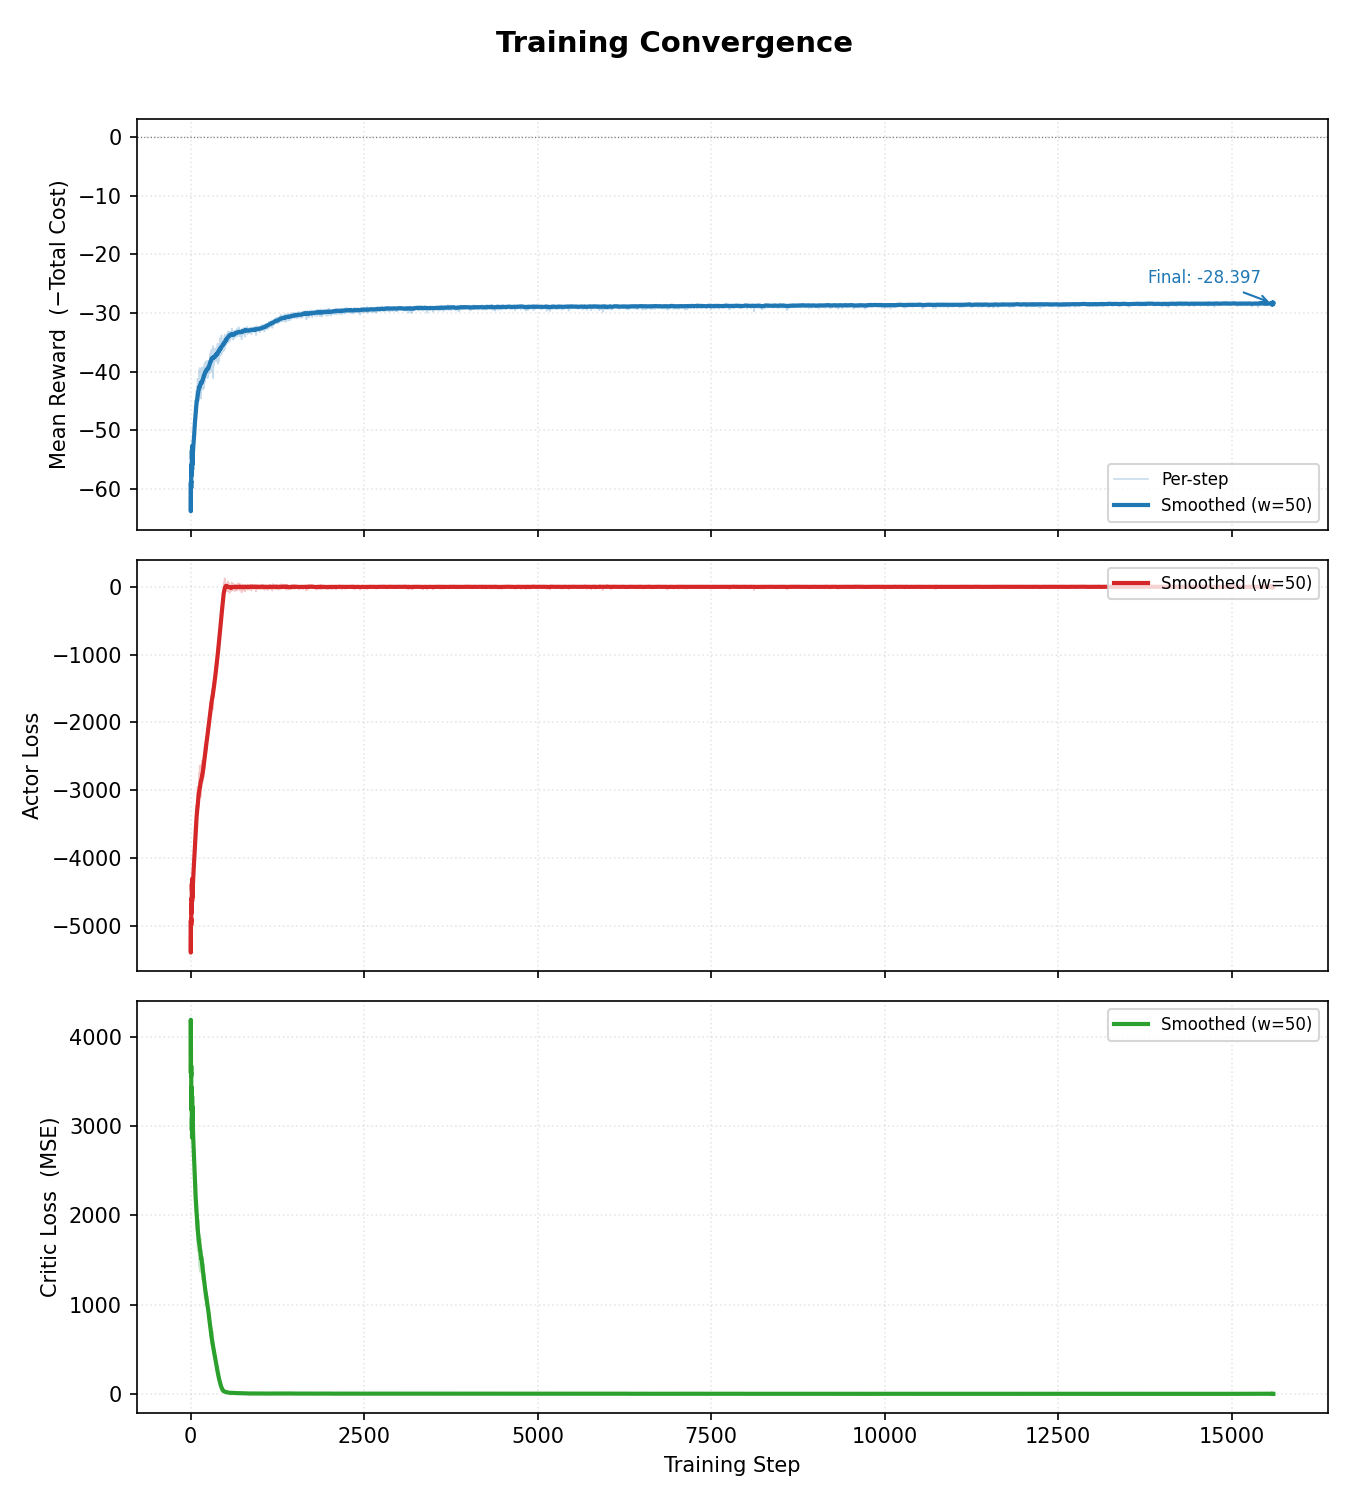

  Not found — run Cell 4 first.


  Not found — run Cell 4 first.


  No route figures yet.


  Searched roots: ['/content', '/content/RL', '/content/drive/MyDrive/Colab Notebooks']
  Found 1 training_history.json file(s):
    - /content/RL/logs/lrp30-2026-06-30_12-55-43/training_history.json

  Saved: /content/figures/training_curves_comparison.png


In [ ]:
import glob, os
from IPython.display import Image, HTML, display

# ── جستجوی چندمسیری — مستقل از working directory فعلی ──────────────────────
# نکته کلیدی: Cell 6 با os.chdir(PROJECT_DIR) به '/content/RL' رفته است،
# پس مسیرهای نسبی مثل 'logs/lrp*/...' دیگر به دایرکتوری training اصلی
# اشاره نمی‌کنند. این نسخه تمام مسیرهای محتمل را با glob جستجو می‌کند.
SEARCH_ROOTS = [
    '/content',
    '/content/RL',
    '/content/drive/MyDrive/Colab Notebooks',
]
DRIVE_LOGS = '/content/drive/MyDrive/Colab Notebooks/logs'
LOCAL_FIGS = '/content/figures'

def section(title):
    display(HTML(
        '<div style="background:#1F4E79;color:white;padding:9px 16px;'
        'border-radius:6px;margin:16px 0 6px;font-family:Arial,sans-serif;">'
        '<b style="font-size:14px">' + title + '</b></div>'
    ))

def find_latest(*patterns):
    files = []
    for p in patterns:
        files.extend(glob.glob(p))
    return sorted(set(files))

def find_all_logs_dirs():
    """جستجوی هر دایرکتوری logs/lrp* در تمام مسیرهای محتمل."""
    found = []
    for root in SEARCH_ROOTS:
        found.extend(glob.glob(os.path.join(root, 'logs', 'lrp*')))
        found.extend(glob.glob(os.path.join(root, '**', 'logs', 'lrp*'), recursive=True))
    return sorted(set(found))


section('📈  Convergence Plot')
conv = find_latest(LOCAL_FIGS + '/convergence.png',
                   DRIVE_LOGS + '/*/figures/convergence.png',
                   '/content/RL/figures/convergence.png',
                   '/content/**/figures/convergence.png')
if conv:
    display(Image(conv[-1], width=820))
else:
    print('  Not found — run training first.')

section('🗺️  California AV Collision Risk Map')
static = find_latest(LOCAL_FIGS + '/california_risk_map_static.png',
                     DRIVE_LOGS + '/*/figures/california_risk_map_static.png',
                     '/content/RL/figures/california_risk_map_static.png')
if static:
    display(Image(static[-1], width=900))
else:
    print('  Not found — run Cell 4 first.')

section('🌐  Interactive Risk Map')
html_map = find_latest(LOCAL_FIGS + '/california_risk_map.html',
                       '/content/RL/figures/california_risk_map.html')
if html_map:
    display(HTML(
        '<iframe src="' + html_map[-1] + '" width="100%" height="560"'
        ' style="border:none"></iframe>'
    ))
else:
    print('  Not found — run Cell 4 first.')

section('🚗  Decoded Route Figures')
route_figs = find_latest(LOCAL_FIGS + '/step*.png',
                         DRIVE_LOGS + '/*/figures/step*.png',
                         '/content/RL/figures/step*.png')
if route_figs:
    for f in route_figs:
        display(Image(f, width=880))
else:
    print('  No route figures yet.')

# ──────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import json

section('📊  Training Curves (multi-scale comparison)')

logs_dirs = find_all_logs_dirs()
history_files = sorted(set(
    os.path.join(d, 'training_history.json')
    for d in logs_dirs
    if os.path.isfile(os.path.join(d, 'training_history.json'))
))

print(f'  Searched roots: {SEARCH_ROOTS}')
print(f'  Found {len(history_files)} training_history.json file(s):')
for hf in history_files:
    print(f'    - {hf}')

if not history_files:
    print('\n  No training history found. Checked relative AND absolute paths')
    print('  under /content, /content/RL, and Google Drive.')
else:
    fig, axes = plt.subplots(1, len(history_files),
                             figsize=(5 * len(history_files), 4))
    if len(history_files) == 1:
        axes = [axes]

    for ax, hf in zip(axes, history_files):
        # نام task را از نام پوشه استخراج کن (مثل lrp100-2026-06-19_10-12-52 → LRP100)
        folder_name = os.path.basename(os.path.dirname(hf))
        task = folder_name.split('-')[0].upper()

        with open(hf) as f:
            hist = json.load(f)

        epoch_costs = [-r for r in hist.get('epoch_reward', [])]

        if not epoch_costs:
            ax.text(0.5, 0.5, f'No epoch_reward data\nin {folder_name}',
                    ha='center', va='center', transform=ax.transAxes)
            continue

        ax.plot(epoch_costs, color='steelblue', linewidth=1.5)
        ax.set_title(f'Model for {task}', fontsize=11)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Total cost')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    out = '/content/figures/training_curves_comparison.png'
    os.makedirs('/content/figures', exist_ok=True)
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\n  Saved: {out}')